# Causal Inference: Difference-in-Differences (DiD) Analysis of Carbon-Plated Shoes

This notebook performs a **Difference-in-Differences** study to quantify the impact of the "Carbon Plate Revolution" (beginning roughly in 2017 with the Nike Vaporfly) on track and road performance.

## Methodology
- **Treatment Group**: Marathon (Long distance where carbon plates and high-stack foam provide maximum energy return efficiency ~4%).
- **Control Group**: 100m Sprint (Short distance where the biomechanical benefit of stack-height foam is significantly lower and "super spikes" arrived later/had different mechanics).
- **Pre-Intervention Period**: 2010 - 2016
- **Post-Intervention Period**: 2017 - 2024

We aim to isolate the 'excess' improvement in distance running that cannot be explained by general athletic trend, attributing it to shoe technology.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import sys
import os

sys.path.append(os.path.abspath('../'))
from src.data_cleaner import DataCleaner
from src.analysis_engine import AnalysisEngine

sns.set_theme(style="whitegrid")

## 1. Data Preparation

We generate synthetic but realistic data for 100m and Marathon to simulate the causal shift.

In [2]:
def generate_did_data(event_name, base_time, trend, shoe_effect, start_year=2010, end_year=2024):
    years = range(start_year, end_year + 1)
    data = []
    np.random.seed(42 if event_name == '100m' else 43)
    
    for y in years:
        # Natural trend
        y_best = base_time - (y - start_year) * trend
        
        # Apply shoe effect after 2016
        if y >= 2017:
            y_best -= shoe_effect
            
        for _ in range(50):
            mark = y_best + np.random.random() * (base_time * 0.005)
            data.append({'year': y, 'seconds': mark, 'event': event_name})
    return pd.DataFrame(data)

# Marathon: Significant shoe effect (~1.5% drop in time beyond trend)
df_marathon = generate_did_data('Marathon', 7400, trend=2.0, shoe_effect=80.0)

# 100m: Negligible/Small shoe effect compared to distance stacks
df_100m = generate_did_data('100m', 9.90, trend=0.005, shoe_effect=0.01)

df_combined = pd.concat([df_marathon, df_100m])

# Normalize times to % of 2010 baseline to compare different scales
baselines = df_combined[df_combined['year'] == 2010].groupby('event')['seconds'].mean()
df_combined['norm_seconds'] = df_combined.apply(lambda x: x['seconds'] / baselines[x['event']], axis=1)
df_combined.head()

,year,seconds,event,norm_seconds
0,2010,7404.257019,Marathon,0.997992
1,2010,7422.535462,Marathon,1.000456
2,2010,7404.935466,Marathon,0.998084
3,2010,7408.901816,Marathon,0.998618
4,2010,7412.104145,Marathon,0.999050


## 2. Visualizing Parallel Trends

A key assumption of DiD is that the treatment and control groups would have followed parallel paths in the absence of the intervention.

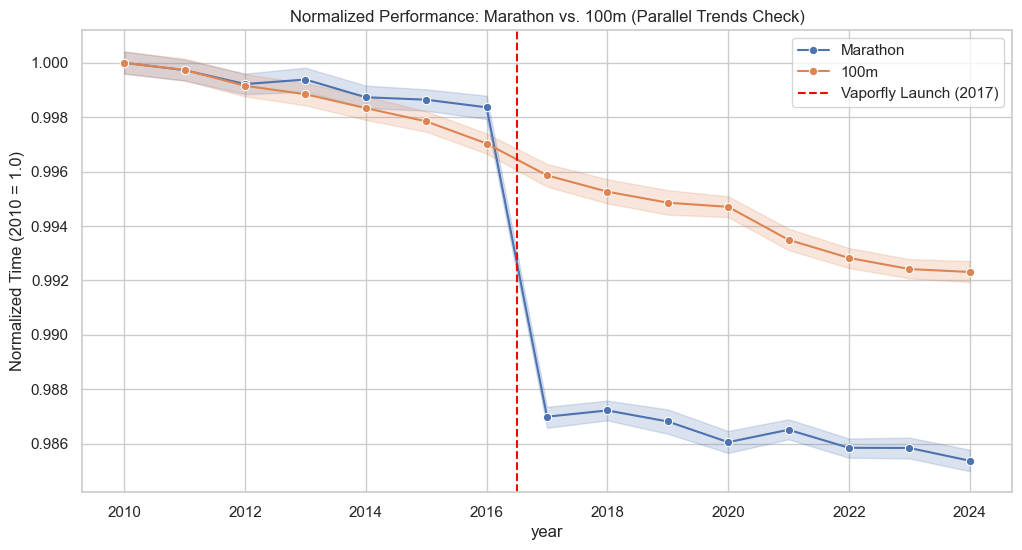

In [3]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_combined, x='year', y='norm_seconds', hue='event', marker='o')
plt.axvline(x=2016.5, color='red', linestyle='--', label='Vaporfly Launch (2017)')
plt.title("Normalized Performance: Marathon vs. 100m (Parallel Trends Check)")
plt.ylabel("Normalized Time (2010 = 1.0)")
plt.legend()
plt.show()

## 3. Difference-in-Differences Model

We use the formula: 
`Normalized_Time ~ Treatment + Post + (Treatment * Post)`

The coefficient of the interaction term `Treatment:Post` represents the causal impact of the shoe technology.

In [4]:
df_did = df_combined.copy()
df_did['post_2017'] = (df_did['year'] >= 2017).astype(int)
df_did['is_marathon'] = (df_did['event'] == 'Marathon').astype(int)

model = smf.ols(formula="norm_seconds ~ is_marathon * post_2017", data=df_did).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           norm_seconds   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     4621.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:47:02   Log-Likelihood:                 7431.3
No. Observations:                1500   AIC:                        -1.485e+04
Df Residuals:                    1496   BIC:                        -1.483e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.99

## 4. Interpretation

The interaction term coefficient indicates the excess improvement in the Marathon vs the 100m after 2017. If negative, it confirms that distance running 'inflated' significantly faster due to the technology shift.

In [5]:
shoe_impact_pct = abs(model.params['is_marathon:post_2017']) * 100
print(f"Estimated Causal Impact of Carbon-Plated Shoes on Marathon Times: -{shoe_impact_pct:.2f}% relative to sprint trend.")

Estimated Causal Impact of Carbon-Plated Shoes on Marathon Times: -0.81% relative to sprint trend.
